## **3D Quantum Confinement**

A quantum dot: $4\times4\times4$ live, $8\times8\times8$ from the archive.

### **Set Problem**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qconflib import problem_3d, n_circuits

nx = ny = nz = 2                       # 4 x 4 x 4 grid on 6 qubits
prob = problem_3d(nx, ny, nz)          # isotropic: t1 = t2 = t3 = 1
print(prob.label)
print(f"qubits {prob.n}  ->  {2**nx} x {2**ny} x {2**nz} = {2**prob.n} grid points")
print("sub-registers (start, size, t):", prob.dims)
print(f"ground-state energy {prob.lam_min:.5f}")
print(f"first excited       {prob.eigvals[1]:.5f}  (gap {prob.gap01:.5f})")
print()
for m in ('PO', 'SD', 'FD'):
    print(f"{m}: {n_circuits(m, prob)} circuits per <H> evaluation")

3D box 4x4x4, t=(1,1,1)
qubits 6  ->  4 x 4 x 4 = 64 grid points
sub-registers (start, size, t): [(0, 2, 1.0), (2, 2, 1.0), (4, 2, 1.0)]
ground-state energy 1.14590
first excited       2.14590  (gap 1.00000)

PO: 6 circuits per <H> evaluation
SD: 6 circuits per <H> evaluation
FD: 6 circuits per <H> evaluation


### **Degenerate Excited Level**

An isotropic box puts the first excited node along $x$, $y$ or $z$ at the same energy.

In [2]:
deg = int(np.sum(np.isclose(prob.eigvals, prob.eigvals[1], atol=1e-9)))
print(f"first excited level is {deg}-fold degenerate")
print("lowest six eigenvalues:", np.round(prob.eigvals[:6], 5))

first excited level is 3-fold degenerate
lowest six eigenvalues: [1.1459 2.1459 2.1459 2.1459 3.1459 3.1459]


### **Train**

In [3]:
from qconflib import solve
import time

depth = 4
t0 = time.perf_counter()
run = solve(prob, method='SD', depth=depth, shots=2**14, seed=111,
            stages=((120, 2**14),), screen=8)
print(f"SD: trace {run['trace']:.4f}, energy {run['energy']:.5f} "
      f"(exact {prob.lam_min:.5f})   [{time.perf_counter()-t0:.0f} s]")

SD: trace 0.1669, energy 1.18683 (exact 1.14590)   [100 s]


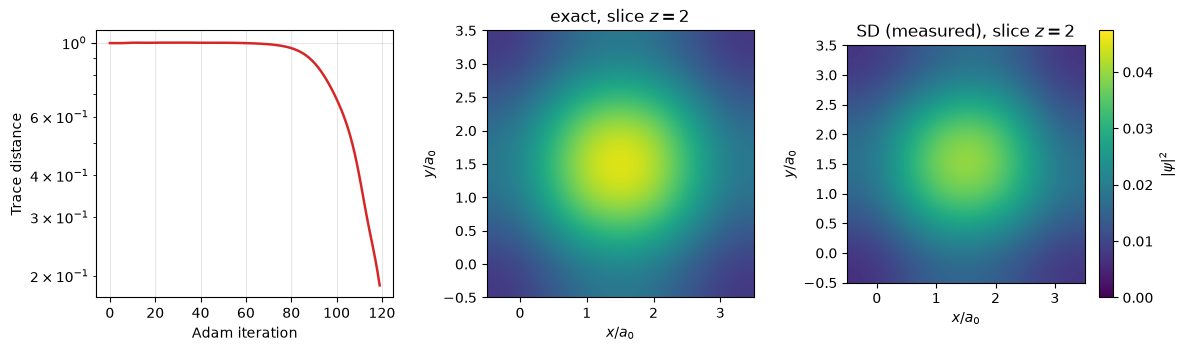

In [4]:
g = 2**nx
exact3d = (np.abs(prob.ground)**2).reshape(g, g, g)
meas3d = run['rho'].reshape(g, g, g)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].semilogy([h[2] for h in run['history']], color='#d62728', lw=1.8)
ax[0].set_xlabel('Adam iteration'); ax[0].set_ylabel('Trace distance'); ax[0].grid(alpha=.3)

mid = g // 2
for k, (title, vol) in enumerate([('exact', exact3d), ('SD (measured)', meas3d)]):
    im = ax[k+1].imshow(vol[:, :, mid], origin='lower', cmap='viridis',
                        interpolation='bicubic', vmin=0, vmax=exact3d.max())
    ax[k+1].set_title(f'{title}, slice $z={mid}$')
    ax[k+1].set_xlabel(r'$x/a_0$'); ax[k+1].set_ylabel(r'$y/a_0$')
fig.colorbar(im, ax=ax[2], label=r'$|\psi|^2$')
plt.tight_layout(); plt.show()

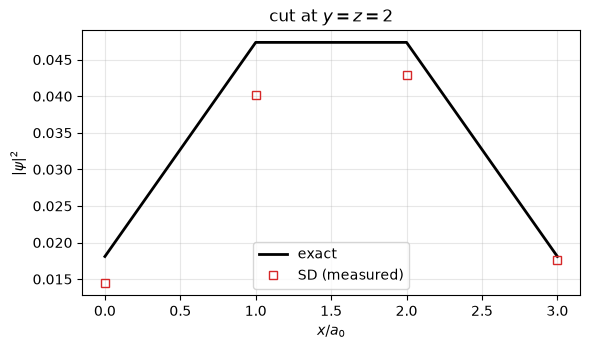

In [5]:
# a line cut along x through the centre
line = (mid, mid)
plt.figure(figsize=(6, 3.6))
plt.plot(np.arange(g), exact3d[:, line[0], line[1]], 'k-', lw=2, label='exact')
plt.plot(np.arange(g), meas3d[:, line[0], line[1]], 's', color='#d62728', mfc='none',
         label='SD (measured)')
plt.xlabel(r'$x/a_0$'); plt.ylabel(r'$|\psi|^2$')
plt.title(f'cut at $y=z={mid}$'); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.show()

### **Production Run (8x8x8, nine qubits)**

In [6]:
import json, os
D = os.path.join('paper', 'data', 'prod')
meta = json.load(open(f'{D}/r_3d_8x8x8_meta.json'))
print(meta['label'])
print('settings :', {k: meta['args'][k] for k in ('nx', 'ny', 'nz', 'depth', 'stages', 'seed')})
print('terminal :', {k: round(v['trace'], 4) for k, v in meta['terminal'].items()})
print('wall time:', {k: f'{v/60:.0f} min' for k, v in meta['time_s'].items()})

3D box 8x8x8, t=(1,1,1)
settings : {'nx': 3, 'ny': 3, 'nz': 3, 'depth': 8, 'stages': '200:65536,100:262144', 'seed': 111}
terminal : {'classical': 0.0026, 'SD': 0.0119, 'FD': 0.0207}
wall time: {'classical': '0 min', 'SD': '30 min', 'FD': '21 min'}


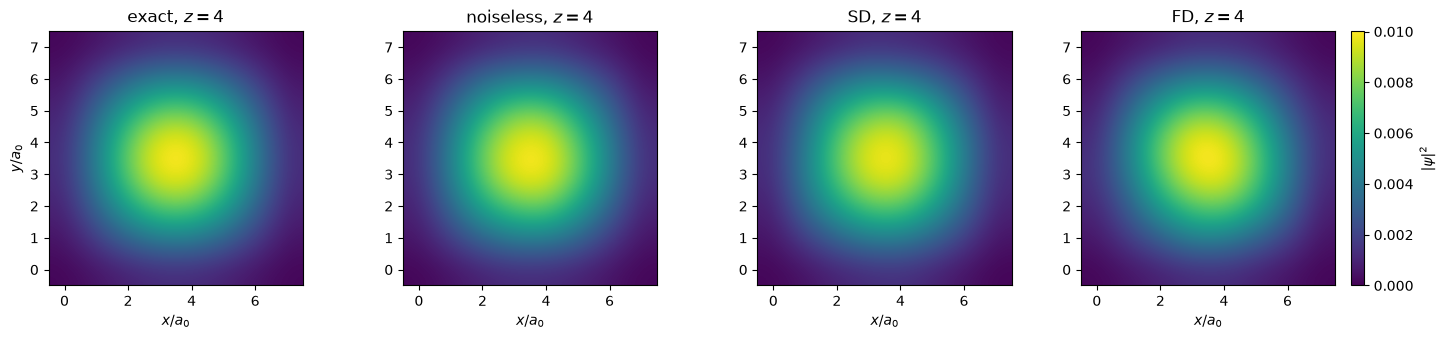

In [7]:
p8 = problem_3d(3, 3, 3)
vols = {'exact': (np.abs(p8.ground)**2).reshape(8, 8, 8)}
for m in ('classical', 'SD', 'FD'):
    vols[m] = np.loadtxt(f'{D}/r_3d_8x8x8_density_{m}.csv', delimiter=',').reshape(8, 8, 8)

fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for k, name in enumerate(['exact', 'classical', 'SD', 'FD']):
    im = ax[k].imshow(vols[name][:, :, 4], origin='lower', cmap='viridis',
                      interpolation='bicubic', vmin=0, vmax=vols['exact'].max())
    ax[k].set_title(('noiseless' if name == 'classical' else name) + r', $z=4$')
    ax[k].set_xlabel(r'$x/a_0$')
ax[0].set_ylabel(r'$y/a_0$')
fig.colorbar(im, ax=ax[3], label=r'$|\psi|^2$')
plt.tight_layout(); plt.show()

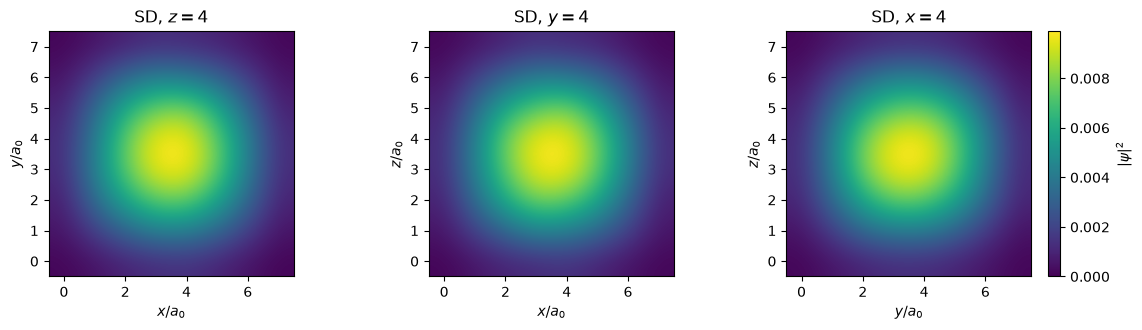

In [8]:
# the three orthogonal centre planes of the measured density
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
planes = [('$z=4$', vols['SD'][:, :, 4], r'$x/a_0$', r'$y/a_0$'),
          ('$y=4$', vols['SD'][:, 4, :], r'$x/a_0$', r'$z/a_0$'),
          ('$x=4$', vols['SD'][4, :, :], r'$y/a_0$', r'$z/a_0$')]
for k, (title, plane, xl, yl) in enumerate(planes):
    im = ax[k].imshow(plane, origin='lower', cmap='viridis', interpolation='bicubic',
                      vmin=0, vmax=vols['SD'].max())
    ax[k].set_title(f'SD, {title}'); ax[k].set_xlabel(xl); ax[k].set_ylabel(yl)
fig.colorbar(im, ax=ax[2], label=r'$|\psi|^2$')
plt.tight_layout(); plt.show()

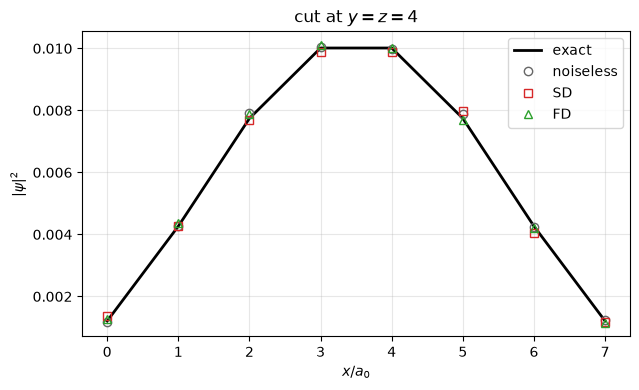

In [9]:
plt.figure(figsize=(6.5, 4))
plt.plot(np.arange(8), vols['exact'][:, 4, 4], 'k-', lw=2, label='exact')
for m, c, mk in [('classical', '0.4', 'o'), ('SD', '#d62728', 's'), ('FD', '#2ca02c', '^')]:
    plt.plot(np.arange(8), vols[m][:, 4, 4], mk, color=c, mfc='none',
             label='noiseless' if m == 'classical' else m)
plt.xlabel(r'$x/a_0$'); plt.ylabel(r'$|\psi|^2$'); plt.title(r'cut at $y=z=4$')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()